In [2]:
'''
Author: Salah Eddine Feddaoui Dellalou
Date: 23-04-2025
Description: This file is the benchmark notebook for Xsuite and mbtrack2 tracking codes
Date de dernière modification: 23-04-2025
'''

'\nAuthor: Salah Eddine Feddaoui Dellalou\nDate: 23-04-2025\nDescription: This file is the benchmark notebook for Xsuite and mbtrack2 tracking codes\nDate de dernière modification: 23-04-2025\n'

## Context:

In this notebook I will showcase how the different codes work in order to simulate intrabeam scattering for the synchrotrons, we will treat the electron booster FCC-ee, since at high energy the instrabeam scattering inside an electron beam is not negligable and should be evaluated.

## Purpos
- This code generate an agreement between Xsuite and Mbtrack using only Synchrotron radiation and no scattering, unmatched bunch imported from xsuite to mbtrack


In [32]:
import json, sys, os, warnings, random, string, shutil, pandas, pickle
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import h5py
import time
import scipy.constants as cons
if not sys.warnoptions:
    warnings.simplefilter("ignore")
from tqdm.notebook import trange
import xtrack as xt
import xpart as xp
import xfields as xf
import xobjects as xo
import xcoll as xc
import xwakes as xw

In [33]:
from mbtrack2 import Synchrotron, Electron
from mbtrack2.utilities import Optics
from mbtrack2.impedance.wakefield import WakeField
from mbtrack2.tracking import LongitudinalMap, SynchrotronRadiation, TransverseMap
from mbtrack2.tracking import IntrabeamScattering
from mbtrack2.tracking import Beam, Bunch, WakePotential
from mbtrack2.tracking import RFCavity, SynchrotronRadiation
from mbtrack2.tracking.monitors import BunchMonitor, WakePotentialMonitor
from mbtrack2.tracking.feedback import FIRDamper, ExponentialDamper
import at

## Loading parameters:

We start by loading the parameters and making the necessary unit conversion for both codes.

In [34]:
class beam_param:
    """
    Class to define the beam parameters from input file
    """
    def __init__(self, mode, **kw):
        if mode == None:
            print('No mode entered -> default = z')
            mode = 'z'
        self.filename()
        self.read_param(mode)
        self.set_param()

    def filename(self):
        # parent_dir = os.path.dirname(os.path.dirname(os.getcwd()))
        input_dir = "_inputs/" #parent_dir + '/_inputs/'
        self.filename = input_dir + 'Booster_parameter_table.json'
        
    def read_param(self, mode):
        inputs_tab = json.load(open(self.filename))
        # print(inputs_tab.keys())

        # define variables
        self.C = inputs_tab['C']['value'] # circumference [m]
        self.Np = inputs_tab['Np'][mode] # number of particles per bunch
        self.Nb = inputs_tab['Nb'][mode] # number of bunches
        self.Etot = inputs_tab['E']['injection'] # energy at injection [eV]
        self.epsnx = inputs_tab['bunch']['epsnx']['value'] # normalised horizontal emittance [m]
        self.epsny = inputs_tab['bunch']['epsny']['value'] # normalised horizontal emittance [m]
        self.sigmaz = inputs_tab['bunch']['sigmaz']['value'] # bunch length at injection [m]
        self.sigmae = inputs_tab['bunch']['sigmae']['value'] # energy spread at injection
        self.Qx = inputs_tab['optics']['Qx'][mode] # horizontal tune
        self.Qy = inputs_tab['optics']['Qy'][mode] # vertical tune
        self.chix = inputs_tab['optics']['chix'][mode] # horizontal chromaticity
        self.chiy = inputs_tab['optics']['chiy'][mode] # horizontal chromaticity
        self.alpha = inputs_tab['optics']['alpha'][mode] # momentum compaction
        self.I2 = inputs_tab['optics']['I2'][mode] # 2nd synchrotron integral
        self.I3 = inputs_tab['optics']['I3'][mode] # 3rd synchrotron integral
        self.I5 = inputs_tab['optics']['I5'][mode] # 5th synchrotron integral
        self.I4 = 5.920335834e-09 # for testing, calculated using MAD-X
        self.I6 = 0 # 6th synchrotron integral
        self.dpt = inputs_tab['optics']['dpt'][mode] # maximum energy acceptance at injection
        self.damp_xy = inputs_tab['optics']['damp_xy'][mode] # transverse damping time at injection energy
        self.damp_s = inputs_tab['optics']['damp_s'][mode] # longitudinal damping time at injection energy
        self.coupling = inputs_tab['optics']['coupling'][mode] # horizontal vertical coupling
        self.Cq = 3.8319e-13
        self.Cgamma = 8.846e-05
        self.Erest = 510998.9499961642 # rest energy [eV]
        self.Egain = 0 # energy gain [eV]
        self.freq = inputs_tab['RF']['RF_freq'][mode] # RF frequency [Hz]
        self.Vtot = inputs_tab['RF']['Vtot'][mode] # total cavities voltage [eV]
        self.Qs = inputs_tab['RF']['Qs_inj'][mode] # synchronous tune at injection
        self.phi_s = inputs_tab['RF']['phis_inj'][mode] # synchronous phase at injection
        
    def set_param(self):
        self.lambdaRF = cons.c/self.freq # RF wavelength
        self.frev = cons.c/self.C # revolution frequency
        self.h = self.freq/self.frev # Schottky number
        self.U0 = self.Cgamma*(self.Etot*1e-9)**4/2/np.pi*self.I2*1e9 # Synchrotron energy loss per turn
        self.gamma = self.Etot / self.Erest
        self.sig_e_eq = np.sqrt(self.Cq*self.gamma**2*self.I3/(2*self.I2))#*(self.Etot*1e-9)**2)
        self.emit_eq = self.Cq * self.gamma**2 * self.I5 / self.I2 # geometrical equilibrium emittance
        self.epsnx_eq = self.emit_eq * self.gamma # normalized equilibrium emittance X
        self.epsny_eq = self.epsnx_eq * 2e-3 # normalized equilibrium emittance Y
        self.eta = 1/self.gamma**2-self.alpha # momentum compaction
#Loading the beam parameters into an object
beam_param = beam_param(mode=None)

No mode entered -> default = z


## Setting defaults
- This cell sets the default parameters, such as number of turns and number of macroparticles, as well as Time that will be used to name the file, both outputs will be named with the same reference date and time with slightly different comment.

In [35]:
temps = time.strftime("%y%m%d_%H%M%S", time.localtime())
comment = "_dx_min_matched_test_xbunch"
n_macroparticles = 100_000
n_turns = 80_000
modelname = 'CIMP'
input_dir = '_inputs/'
output_dir = '_outputs/'
optics_file = input_dir + 'heb_ring_withcav.json' # optics file
lattice =  input_dir + 'V24_1FODO_02.mat'
mass =xp.ELECTRON_MASS_EV # mass of the particle
q0 = -1 # charge of the particle
mbtrack2_output = output_dir + modelname+"_jupyter_"+temps+comment
chunk_size = 10
n_chunk = int(np.ceil(n_turns/chunk_size))
ibs_slicing = 10
# beam_param.damp_xy = 8.940073794
# beam_param.damp_s = 4.470036897
# beam_param.U0 = 1.360723085e6
# beam_param.U0 = 1.360723085e6
# beam_param.Vtot = 62e6
# beam_param.sigmae = 0.0033
# beam_param.sigmaz = 0.0012
# beam_param.gamma = 39139.02368

## Setting Line
- Setting the line from which we will take the twiss parameters to build the map for both codes.

In [36]:
# twiss parameters for xsuite
context = xo.ContextCpu(omp_num_threads="auto")

line = xt.Line.from_json(optics_file)
particle_ref = xp.Particles(mass0=mass, q0=q0, gamma0=beam_param.gamma)
line.particle_ref = particle_ref

line.slice_thick_elements( slicing_strategies=[
xt.Strategy(slicing=xt.Teapot(2)), 
xt.Strategy(slicing=xt.Teapot(3), element_type=xt.Bend), 
xt.Strategy(slicing=xt.Teapot(5), element_type=xt.Quadrupole), 
xt.Strategy(slicing=xt.Teapot(3), element_type=xt.Sextupole)])
line.build_tracker()
line.configure_radiation(model='mean')
environment = line.env
tw = line.twiss(method="6d" ,eneloss_and_damping=True)
C =  tw.s[-1] # circumference
qx =  tw.qx # horizontal tune
qy =  tw.qy # vertical tune
dqx =  tw.dqx # horizontal chromaticity
dqy =  tw.dqy # vertical chromaticity
eneloss_turn = tw.eneloss_turn
df = tw.to_pandas()
betax_0 = beam_param.C / (2*np.pi*tw.qx) # should be tweaked
# betax_0 = 54.4
df["distance"] = abs(df.betx - betax_0)
smallest = df.nsmallest(10, 'distance')
smallest = smallest.drop('distance', axis=1)
index = smallest.dx.idxmin()
alphax = smallest.alfx[index] 
alphay = smallest.alfy[index] 
dx = smallest.dx[index] 
dy = smallest.dy[index]
betax = smallest.betx[index]
betay = smallest.bety[index]
dpx = smallest.dpx[index]
dpy = smallest.dpy[index]

Loading line from dict:   0%|          | 0/34804 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/34804 [00:00<?, ?it/s]

## Building the map
- We define the noise parameters that will give us the synchrotron damping, and we give them to the map function.

In [6]:
betax_0 = beam_param.C / (2*np.pi*tw.qx) # should be tweaked
df["distance"] = abs(df.betx - betax_0)
smallest = df.nsmallest(10, 'distance')
smallest = smallest.drop('distance', axis=1)
index = smallest.dx.idxmin()
alphax = smallest.alfx[index] 
alphay = smallest.alfy[index] 
dx = smallest.dx[index] 
dy = smallest.dy[index]
betax = smallest.betx[index]
betay = smallest.bety[index]
dpx = smallest.dpx[index]
dpy = smallest.dpy[index]

print(dx)
print(dpx)
print(betax)
print(alphax)
print(betay)

print("betax_0" , beam_param.C / (2*np.pi*tw.qx)) # should be tweaked


-1.3378653780508278e-06
-6.377248346032698e-08
34.83771643330359
-0.7743917072009355
180.01305702931992
betax_0 34.83343667404496


In [56]:
dx 0.1028170559952194
bx 32.942356132778876
ax 1.2492702499797281
betay 48.77965803686419


"""""
0.10281705625569051
-0.00263116435609055
32.942356133075705
1.2492702500270212
48.77965803686363
betax_0 34.83343667404496

SyntaxError: invalid syntax (2722173036.py, line 1)

In [52]:
with h5py.File("_outputs/input_CIMP_250630_164211_65062152_ibs_mbt_context-40_loc02_32.942356133075705.hdf5", 'r') as f:
    print(f["parameters"])
    group = f["parameters"]
    print(group["chosen_params"])

<HDF5 group "/parameters" (1 members)>
<HDF5 dataset "chosen_params": shape (), type "|O">


In [37]:
det_= line.get_amplitude_detuning_coefficients(
    nemitt_x=beam_param.epsnx, 
    nemitt_y=beam_param.epsny, 
    num_turns=500, 
    a0_sigmas=0.01, 
    a1_sigmas=0.1, 
    a2_sigmas=0.2
)
damping_rate_emit_h = 2 * tw.damping_constants_turns[0] # horizontal damping rate
damping_rate_emit_v = 2 * tw.damping_constants_turns[1] # horizontal damping rate
damping_rate_emit_zeta = 2 * tw.damping_constants_turns[2] # longitudinal damping rate

N = len(tw.betx)
rand = np.random.standard_normal(size=N)
rand = abs(rand)


gauss_noise_ampl_px = 2 * np.sqrt(tw.eq_gemitt_x *(1)* damping_rate_emit_h / betax) 
gauss_noise_ampl_x = 0
gauss_noise_ampl_py = 2 * np.sqrt(tw.eq_gemitt_y *(1)* damping_rate_emit_h / betay) 
gauss_noise_ampl_y = 0
gauss_noise_ampl_delta = 2 * np.sqrt(tw.eq_gemitt_zeta *.5  *damping_rate_emit_zeta / tw.bets0) 
T = beam_param.damp_xy *cons.c / beam_param.C
tau = 2 / T

gauss_noise_ampl_delta = np.average(gauss_noise_ampl_delta)
gauss_noise_ampl_x = np.average(gauss_noise_ampl_x)
gauss_noise_ampl_px = np.average(gauss_noise_ampl_px)
gauss_noise_ampl_y = np.average(gauss_noise_ampl_y)
gauss_noise_ampl_py = np.average(gauss_noise_ampl_py)

det_xx = det_['det_xx']
det_yy = det_['det_yy']
det_xy = det_['det_xy']
det_yx = det_['det_yx']
map_line =  xt.LineSegmentMap(
                    length=beam_param.C,
                    qx=beam_param.Qx,
                    qy=beam_param.Qy,
                    dqx=tw.dqx,
                    dqy=tw.dqy,
                    momentum_compaction_factor=beam_param.alpha,
                    betx=betax,
                    bety=betay,
                    alfx=alphax,
                    alfy=alphay,
                    dx = dx,
                    dpx = dpx,
                    dpy = dpy,
                    dy = dy,
                    det_xx=det_xx,
                    det_xy=det_xy,
                    det_yx=det_yx,
                    det_yy=det_yy,  
                    damping_rate_x=  damping_rate_emit_h,
                    damping_rate_y=  damping_rate_emit_v,
                    # In longitudinal all damping goes on the momentum
                    damping_rate_zeta=0,
                    damping_rate_pzeta=damping_rate_emit_zeta,
                    gauss_noise_ampl_px=gauss_noise_ampl_px,
                    gauss_noise_ampl_py=gauss_noise_ampl_py,
                    gauss_noise_ampl_pzeta=gauss_noise_ampl_delta,
                    energy_increment           = -1 * tw.eneloss_turn,#M.U0,
                    longitudinal_mode          = 'nonlinear', # needs to be commented for 4D tracking + uncomment betas/qs
                    voltage_rf                 = [beam_param.Vtot], # needs to be commented for 4D tracking + uncomment betas/qs
                    frequency_rf               = [beam_param.freq], # needs to be commented for 4D tracking + uncomment betas/qs
                    lag_rf                     = [180 - np.rad2deg(np.arcsin(tw.eneloss_turn/beam_param.Vtot))], # needs to be commented for 4D tracking + uncomment betas/qs
                )

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


## Building the map for mbtrack2
- Here we build the map for mbtrack2 and we do that by defining the parameters and calling Synchrotron function without loading lattice, we use the same optics parameters that were extracted from Line.

In [38]:
#we define twiss parameters for mbtrack2
def v24(parameter = beam_param, lattice = lattice):
    """
    read lattice .mat format (loaded with AT) and returns ring object
    Takes Parameters from beam_param class

    Returns
    -------
    ring : Synchrotron object

    """    
    load_lattice = False 
    ####################
    h = parameter.h
    particle = Electron()
    tau =   np.array([parameter.damp_xy, parameter.damp_xy, parameter.damp_s]) #np.array([11.49, 11.49, 5])   
    sigma_0 = parameter.sigmaz/cons.c
    sigma_delta = parameter.sigmae
    emit = np.array([parameter.epsnx/parameter.gamma, parameter.epsny/parameter.gamma])
    f0 = parameter.frev #Revolution frequency in [Hz].
    f1 = parameter.freq # Fundamental RF frequency in [Hz].
    U0 = parameter.U0
    ac = parameter.alpha
    lattice_file = lattice
    chro = np.array([parameter.chix, parameter.chiy])
    gamma = parameter.gamma
    tune = np.array([parameter.Qx, parameter.Qy])
    local_alpha = np.array([alphax,alphay])#np.array([np.average(tw.alfx), np.average(tw.alfy)])
    local_beta = np.array([betax, betay])#np.array([np.average(tw.betx), np.average(tw.bety)])
    local_disp = np.array([dx,dpx,dy,dpy])
    L = beam_param.C
    E0=beam_param.Etot

    if load_lattice == True:
        optics = Optics(lattice_file=lattice_file, n_points=1e4)
        ring = Synchrotron(h, optics, particle, tau=tau,emit=emit, 
                   sigma_0=sigma_0, sigma_delta=sigma_delta, f0=f0, f1=f1, U0=U0, ac=ac, chro=chro, gamma=gamma, tune=tune)
    else:
        optics = Optics(local_alpha=local_alpha,local_beta=local_beta,local_dispersion=local_disp, n_points=1e4)
        ring = Synchrotron(h, optics, particle, tau=tau,emit=emit, 
                   sigma_0=sigma_0, sigma_delta=sigma_delta, f0=f0, f1=f1, U0=U0, ac=ac, chro=chro, gamma=gamma, L=L, E0=E0,tune=tune)

    
    return ring

ring = v24()

In [39]:
#associating  the map to  the line
ring_map_no_excit = map_line.copy()
environment.elements['ring_map'] = map_line
ring_map_no_excit.gauss_noise_matrix = 0
ring_map = xt.Line(elements=[ring_map_no_excit])
ring_map._needs_rng = True
ring_map.particle_ref = particle_ref.copy()
tw_check = ring_map.twiss()
ring_map.correct_trajectory(twiss_table=ring_map.twiss4d())

- We create an object that holds the map for this notebook, however for IBS we need to include the IBS kick in the same object
- **This cell should be ignored when running the simulation for IBS**

In [40]:
environment.elements["ring_map"] = map_line
line_map = environment.new_line(name="line_map", components=["ring_map"])

line_map.particle_ref = particle_ref.copy()
line_map._needs_rng = True
# line_map.build_tracker()

## Generating the bunch for mbtrack2

In [41]:
# Generating bunch for mbtrack2
bunch_current = beam_param.Np * cons.elementary_charge * cons.c / beam_param.C 
particle = Electron()

mybunch = Bunch(
    ring, mp_number=n_macroparticles, current=bunch_current, track_alive=True)
np.random.seed(42)
rng = np.random.RandomState(42)
mybunch.init_gaussian()

## Generating the bunch for Xsuite
- There are two methods, matched and unmatched, comment the one you don't need

In [42]:
# Generating bunch for xsuite
rng = np.random.RandomState(42)

#############################################
x_norm = rng.randn(n_macroparticles)
px_norm = rng.randn(n_macroparticles)
y_norm = rng.randn(n_macroparticles)
py_norm = rng.randn(n_macroparticles)
zeta = beam_param.sigmaz * (rng.randn(n_macroparticles))
delta = beam_param.sigmae * (rng.randn(n_macroparticles))
################################################

#################### Matched Bunch ############################
# particles = xp.generate_matched_gaussian_bunch(
#                 num_particles=n_macroparticles,
#                 nemitt_x=beam_param.epsnx,
#                 nemitt_y=beam_param.epsny,
#                 sigma_z=beam_param.sigmaz,
#                 # rf_harmonic=1,
#                 # rf_voltage= beam_param.Vtot,
#                 # rf_phase=180 - np.rad2deg(np.arcsin(tw.eneloss_turn/beam_param.Vtot)),
#                 # energy_ref_increment=-1 * tw.eneloss_turn,
#                 # particle_ref=particle_ref,
#                 total_intensity_particles=beam_param.Np,
#                 line=ring_map, _context = context)

################### Unmatched Bunch ##############################
particles = ring_map.build_particles(
    _context=context, 
    _buffer=None, 
    _offset=None,
    particle_ref=particle_ref,
    zeta=zeta, 
    delta=delta,
    x_norm=x_norm, 
    px_norm=px_norm,
    y_norm=y_norm, 
    py_norm=py_norm,
    nemitt_x=beam_param.epsnx, 
    nemitt_y=beam_param.epsny,

    weight=beam_param.Np/n_macroparticles)

# Emittance calculation

- in this cell we give Xsuite bunch to mbtrack2 this will assure that we are starting from the same initial conditions using the same bunch

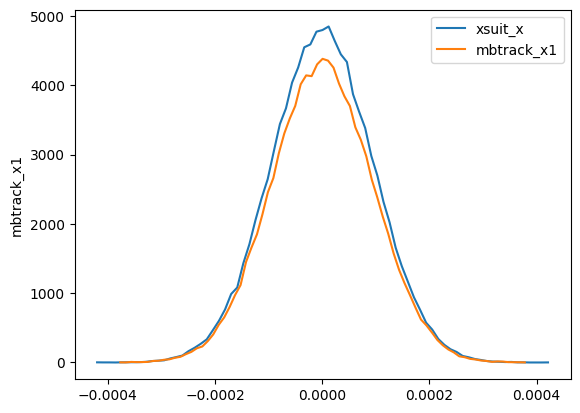

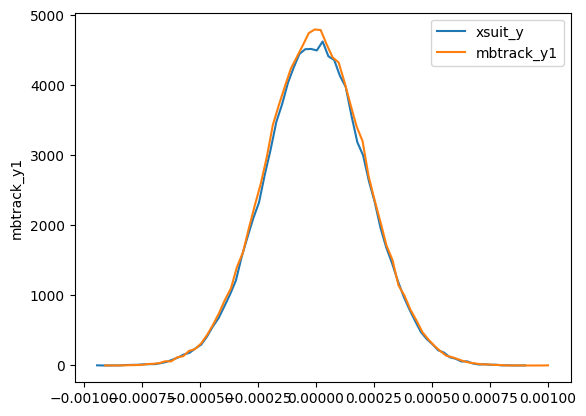

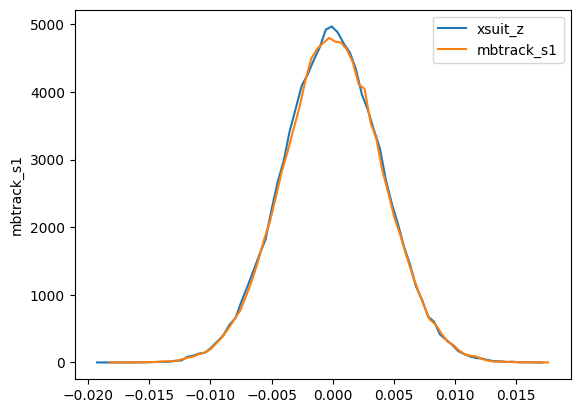

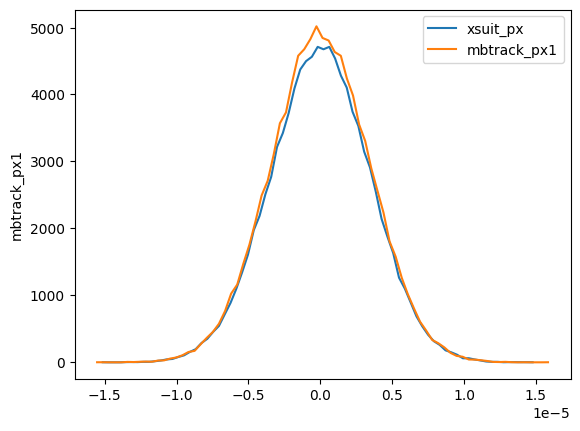

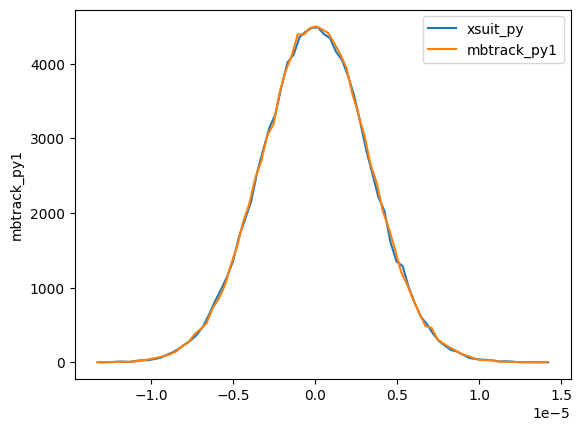

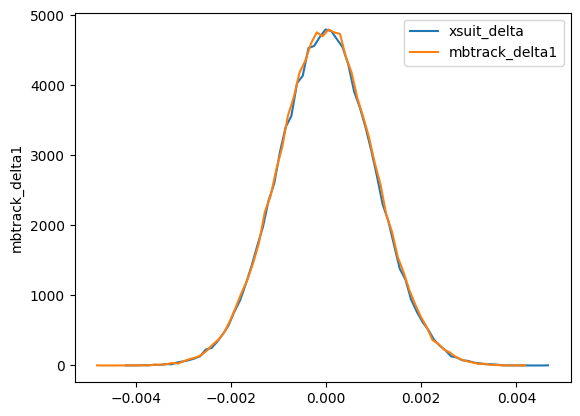

In [43]:
%matplotlib inline
n_bin = 75

x = np.array(particles.x)
px = np.array(particles.px)
y = np.array(particles.y)
py = np.array(particles.py)
z = np.array(particles.zeta)
delta = np.array(particles.delta)


x1 = np.array(mybunch["x"])
xp1 = np.array(mybunch["xp"])
y1 = np.array(mybunch["y"])
yp1 = np.array(mybunch["yp"])
s1 = np.array(mybunch["tau"])
s1 = s1*cons.c
delta1 = np.array(mybunch["delta"])


dimensions = [x,y,z,x1,y1,s1]
dims = {"xsuit_x":x, "mbtrack_x1":x1, "xsuit_y":y, "mbtrack_y1":y1, "xsuit_z":z, "mbtrack_s1":s1, "xsuit_px":px, "mbtrack_px1":xp1, "xsuit_py":py, "mbtrack_py1":yp1, "xsuit_delta":delta, "mbtrack_delta1":delta1 }
i = 0
for el, val in dims.items():
    bin_min = val.min()
    bin_min = min(bin_min * 0.99, bin_min * 1.01)
    bin_max = val.max()
    bin_max = max(bin_max * 0.99, bin_max * 1.01)
    bins = np.linspace(bin_min, bin_max, n_bin + 1)
    center = (bins[1:] + bins[:-1]) / 2
    sorted_index = np.searchsorted(bins, val, side="left")
    sorted_index -= 1
    profile = np.bincount(sorted_index, minlength=n_bin)
    plt.plot(center, profile, label=str(el))
    plt.ylabel(el)
    plt.legend()
    i+=1
    if i == 2 :
        plt.show()
        i = 0
 


## Setting synchrotron radiation tracker for mbtrack2

In [44]:
# Synchrotron radiation mbtrack2
sr = SynchrotronRadiation(ring, switch=[1, 1, 1])

## Setting Cavity tracker for mbtrack2
- Setting the equilibrium emittance and equilibrium spread, since mbtrack takes those parameters once and use them to create a bunch, that usually gives us an oscillation around the initial value making seeing the damping not possible, this approach provides such results.

In [45]:
# Setting Cavity for mbtrack2
ring.emit = np.array([beam_param.epsnx_eq / beam_param.gamma, beam_param.epsny_eq / beam_param.gamma])
factor =  beam_param.C * np.sqrt((beam_param.alpha * beam_param.Etot)/(2*np.pi * beam_param.h*((beam_param.Vtot**2 - beam_param.U0**2)**0.5)))
sig_p0_2 = beam_param.Cq * beam_param.gamma**2 * beam_param.I3 / ((beam_param.I2 * 2)+ beam_param.I4) 
sig_p0 = np.sqrt(sig_p0_2)
ring.sigma_delta = sig_p0 
ring.sigma_0 = (sig_p0 * factor )/cons.c

V_rf  = beam_param.Vtot
theta = 0.0
# theta = -1*np.arccos(beam_param.U0/beam_param.Vtot)
theta_in_cc2 =  np.arccos(beam_param.U0/beam_param.Vtot)

rf = RFCavity(ring, m=1, Vc=V_rf, theta=theta_in_cc2)

## Setting mbtrack2 monitor

In [15]:
# Setting monitor for mbtrack2
monitor_mbtrack = BunchMonitor(1, 1,buffer_size=10, total_size=n_turns, file_name=mbtrack2_output)

- Setting Xsuite monitor

In [16]:
# Setting Monitor for xsuite
emit_mon = xc.EmittanceMonitor.install(line=line_map, name="EmittanceMonitor", at=0, stop_at_turn=n_turns)

## Setting line map trackers

In [17]:
# Tracking line for mbtrack2
long_map = LongitudinalMap(ring)
trans_map = TransverseMap(ring)

In [23]:
some_dict = {"value": []}

for i in range(10):
    some_dict["value"].append(i)

print(some_dict)

{'value': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}


In [18]:
#Tracking using mbtrack2
emit_x_mb = {"emitx": []}
tracking_elements = [trans_map,long_map, rf, sr]
for i in trange(n_turns):
    for el in tracking_elements:
        el.track(mybunch)
    # val = np.std(mybunch["x"])**2 / tw.betx
    # val = (ring.optics.gamma(s)[0] * np.std(mybunch['x'])**2) + (2 * ring.optics.alpha(s)[0] * np.std(mybunch['x']) * np.std(mybunch['xp'])) + (ring.optics.beta(s)[0] * np.std(mybunch['xp'])**2) 
    # emit_x_mb["emitx"].append(val.mean())
    monitor_mbtrack.track(mybunch)

  0%|          | 0/80000 [00:00<?, ?it/s]

- Tracking using Xsuite and saving data

In [19]:
#Tracking using Xsuite
emit_x_s = []
mean_x  = []
mean_y  = []
mean_z  = []
mean_e = []
sigma_x = []
sigma_y = []
sigma_z = []
sigma_e = []
for i_chunk in trange(n_chunk):
    monitor = xt.ParticlesMonitor(_context= context,start_at_turn=i_chunk*chunk_size, stop_at_turn=(i_chunk+1)*chunk_size,num_particles=n_macroparticles)   
    line_map.track(particles, num_turns=chunk_size, turn_by_turn_monitor=monitor, with_progress=False)
    mean_x[i_chunk*chunk_size : (i_chunk+1)*chunk_size] = np.average(monitor.x, axis=0)
    mean_y[i_chunk*chunk_size:(i_chunk+1)*chunk_size]   = np.average(monitor.y,axis=0)
    mean_z[i_chunk*chunk_size:(i_chunk+1)*chunk_size]   = np.average(monitor.zeta,axis=0)
    mean_e[i_chunk*chunk_size:(i_chunk+1)*chunk_size]   = np.average(monitor.delta,axis=0)
    sigma_x[i_chunk*chunk_size:(i_chunk+1)*chunk_size]  = np.std(monitor.x,axis=0)
    sigma_y[i_chunk*chunk_size:(i_chunk+1)*chunk_size]  = np.std(monitor.y,axis=0)
    sigma_z[i_chunk*chunk_size:(i_chunk+1)*chunk_size]  = np.std(monitor.zeta,axis=0)
    sigma_e[i_chunk*chunk_size:(i_chunk+1)*chunk_size]  = np.std(monitor.delta,axis=0)
    emit_x_s[i_chunk*chunk_size:(i_chunk+1)*chunk_size] = ((np.std(monitor.x, axis=0)**2 - (dx*np.std(monitor.delta, axis=0))**2)) / betax


    

  0%|          | 0/8000 [00:00<?, ?it/s]

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


- Saving Xsuite tracked data into a file

In [20]:
output = {
    'epsx' : {
        'value' : list(emit_x_s),
        'label' : r'$\epsilon_x$'
    },
    'epsy' : {
        'value': emit_mon.gemitt_y.tolist(),
        'label': r'$\epsilon_y$'
    },
    'epsz' : {
        'value': emit_mon.gemitt_zeta.tolist(),
        'label': r'$\epsilon_z$'
    },
    'meanx' : {
        'value': list(mean_x),
        'label' : r'$\bar{x}$'
    },
    'meany' : {
        'value': list(mean_y),
        'label' : r'$\bar{y}$'
    },
    'meanz' : {
        'value': list(mean_z),
        'label' : r'$\bar{z}$'
    },
    'meane' : {
        'value': list(mean_e),
        'label' : r'$\bar{e}$'
    },
    'sigmax' : {
        'value': list(sigma_x),
        'label' : r'$\sigma_x$'
    },
    'sigmay' : {
        'value': list(sigma_y),
        'label' : r'$\sigma_y$'
    },
    'sigmaz' : {
        'value': list(sigma_z),
        'label' : r'$\sigma_z$'
    },
    'sigmae' : {
        'value' : list(sigma_e),
        'label' : r'$\sigma_e$'
    },
    # 'inputs' : self._inputs,
    'parameters': vars(beam_param),
    # 'comment' : self.comments
}
comment = f"unmatched_dx--{dx}_dpx--{dpx}"
filename = '_outputs/xsuite_jupyter_'+temps+'_'+comment+'.json'
with open(filename, 'w') as json_file:
    json.dump(output, json_file)
print("Done!")

Done!


In [47]:
#############################################json cell###################################
file_name = "output_250411_091713.json"
with open("_outputs/xsuite_jupyter_250702_134124_unmatched_dx---1.3378653780508278e-06_dpx---6.377248346032698e-08.json") as f:
    outputs = json.load(f)

parameters = vars(beam_param)
emitx = outputs["epsx"]
emit_x = np.array(emitx['value'])
D_t = parameters["C"] /cons.c

emit_y = np.array(outputs["epsy"]["value"])
emit_z = np.array(outputs["epsz"]["value"]) / cons.c
mean_x = np.array(outputs["meanx"]["value"])
mean_y = np.array(outputs["meany"]["value"])
mean_z = np.array(outputs["meanz"]["value"])
sig_z = np.array(outputs["sigmaz"]["value"])
sig_p = np.array(outputs["sigmae"]["value"])

TT = np.arange(len(emit_x)) * D_t
print("Starting emittance[pm]:",emit_x[0]*1e12)
print("Final emittance[pm]:",emit_x[-1]*1e12)

Starting emittance[pm]: 257.23871246529126
Final emittance[pm]: 35.000941614931264


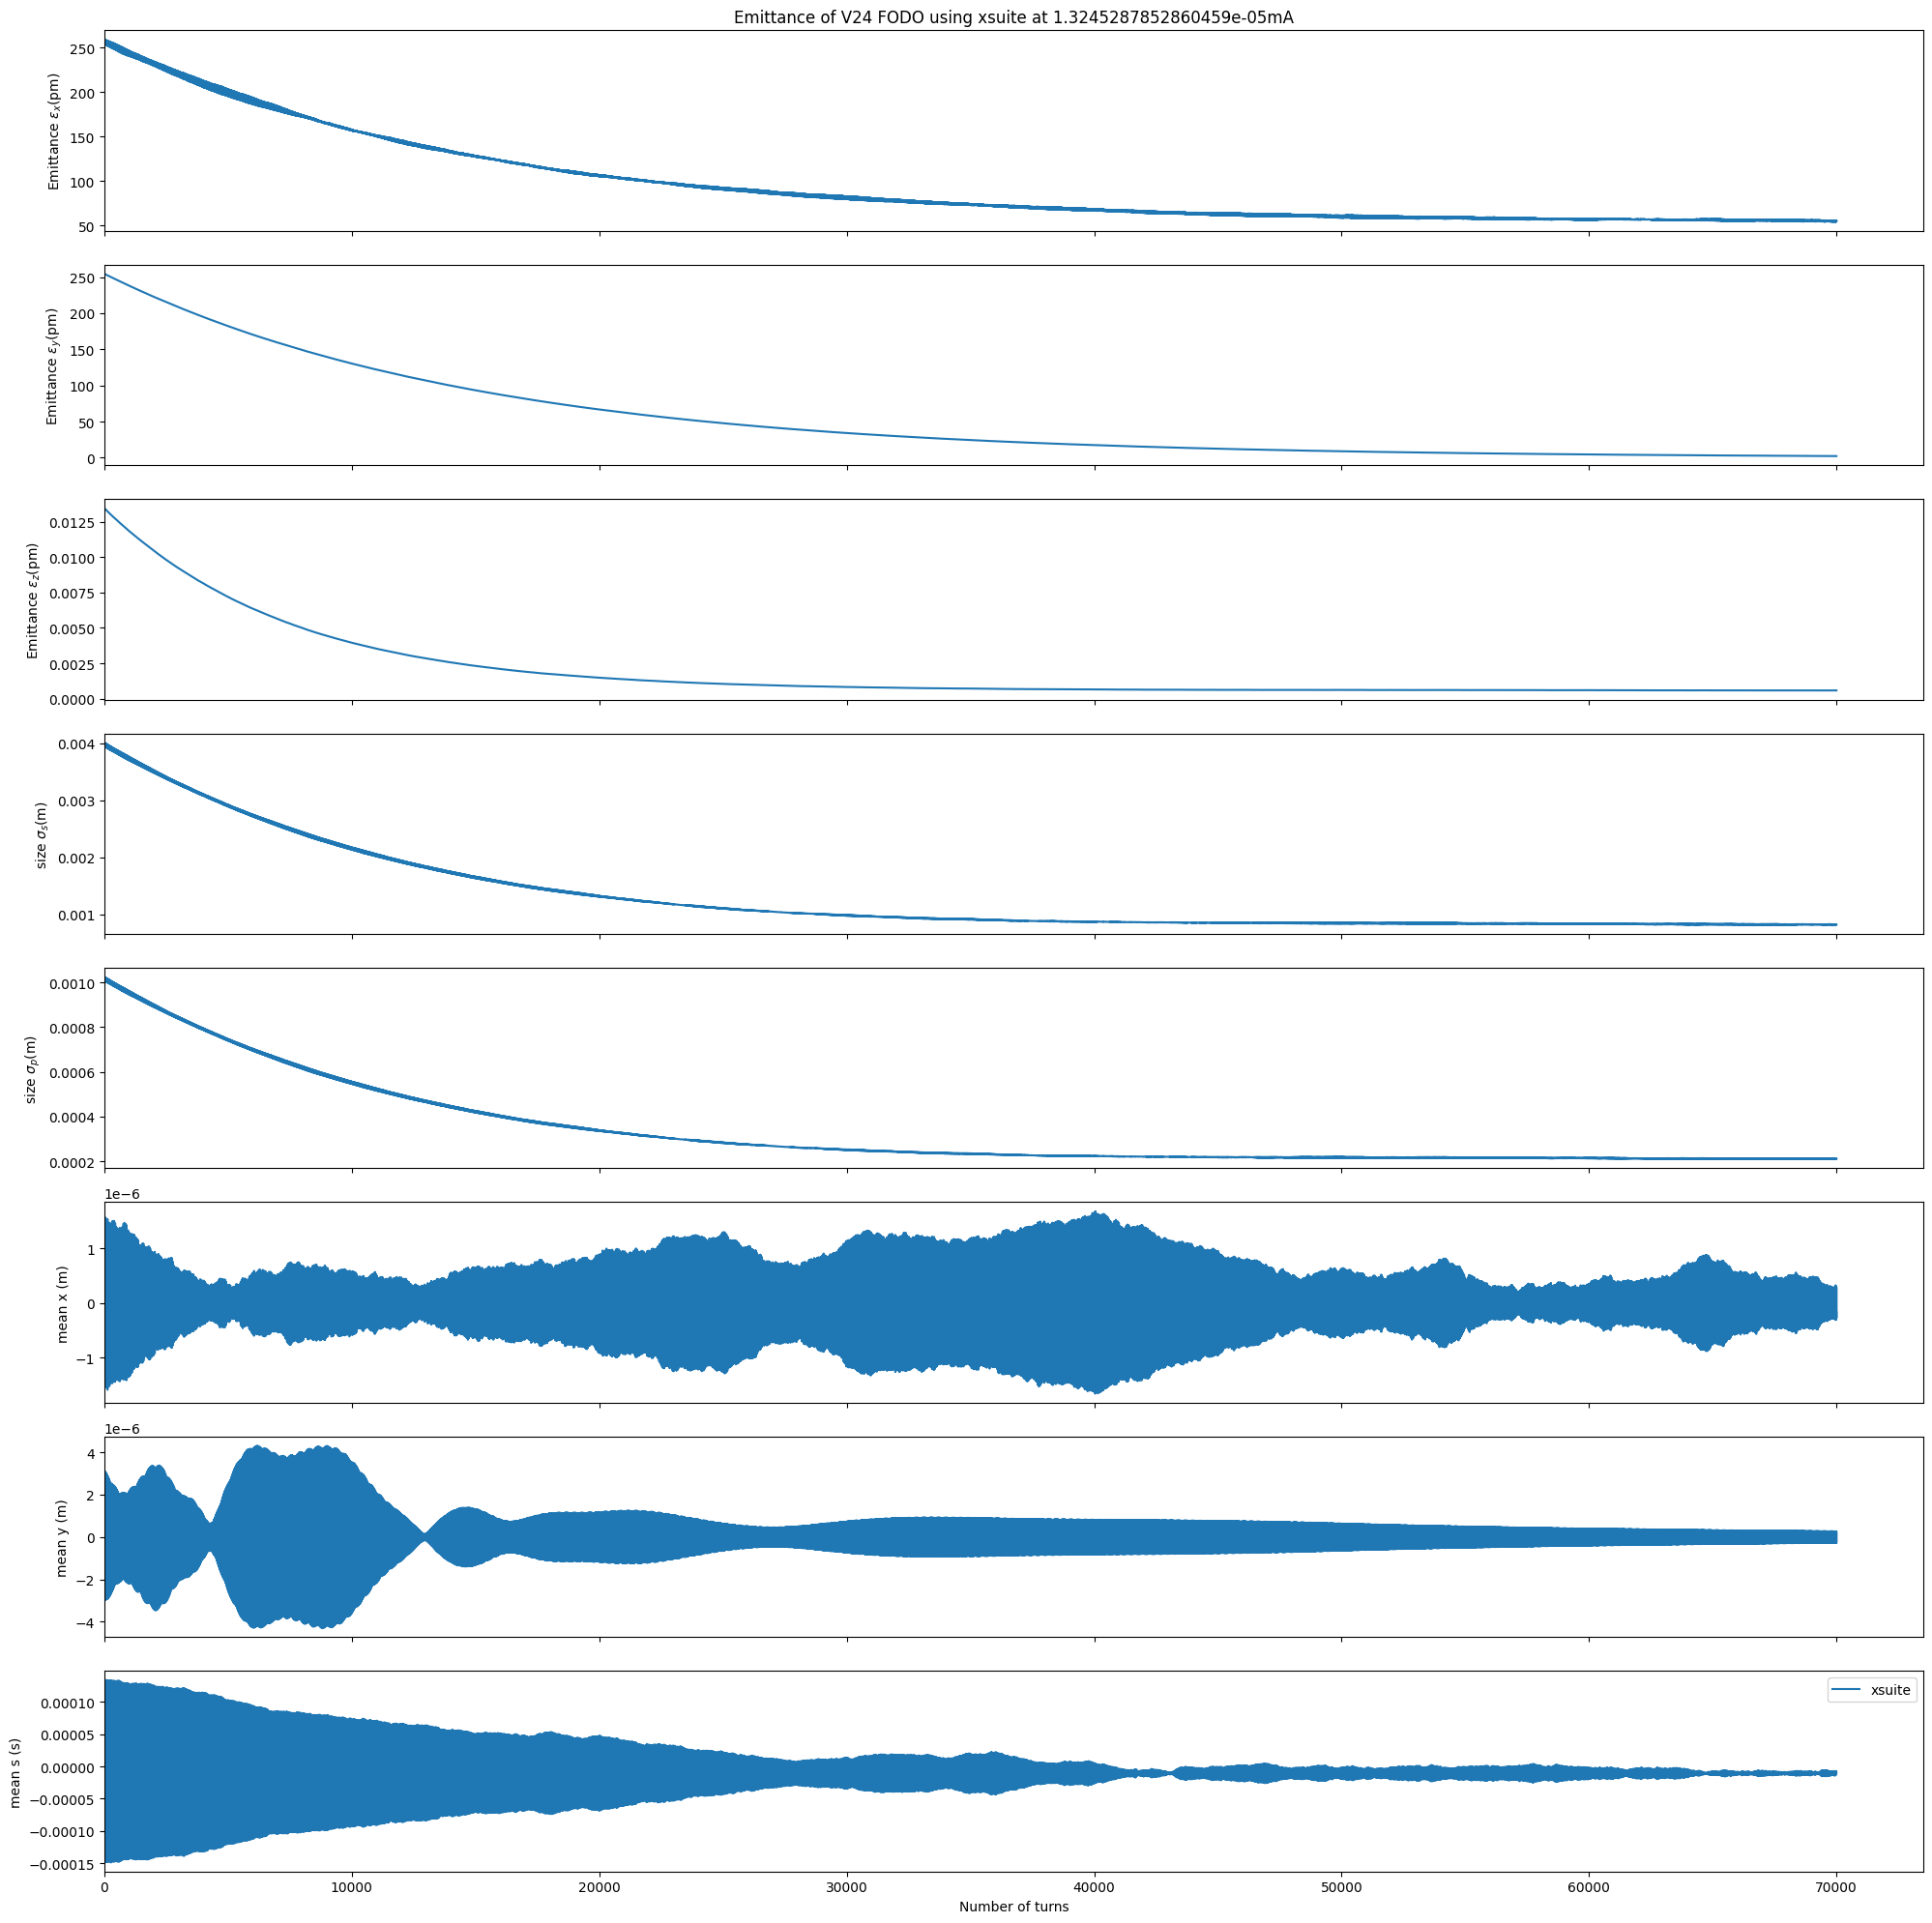

In [16]:
fig, axes = plt.subplots(8, 1, figsize=(20, 20), sharex=True)

x = np.arange(n_turns)

axes[0].plot(emit_x*1e12, label="xsuite")
axes[0].set_ylabel(r"Emittance $\epsilon_{x}$(pm)")
axes[0].set_title(f"Emittance of V24 FODO using xsuite at {D_Q/D_t}mA")

axes[1].plot(emit_y*1e12, label="xsuite")
axes[1].set_ylabel(r"Emittance $\epsilon_{y}$(pm)")

axes[2].plot(emit_z*1e12, label="xsuite")
axes[2].set_ylabel(r"Emittance $\epsilon_{z}$(pm)")

axes[3].plot(sig_z, label="xsuite")
axes[3].set_ylabel(r"size $\sigma_{s}$(m)")


axes[4].plot(sig_p, label="xsuite")
axes[4].set_ylabel(r"size $\sigma_{p}$")


axes[5].plot(mean_x, label="xsuite")
axes[5].set_ylabel(r"mean x (m)")

axes[6].plot(mean_y, label="xsuite")
axes[6].set_ylabel(r"mean y (m)")


axes[7].plot(mean_z, label="xsuite")
axes[7].set_ylabel(r"mean s (s)")
axes[7].set_xlabel("Number of turns")
plt.xlim(0,)
plt.tight_layout()

plt.legend()
plt.show()

In [49]:
#############################################   hdf5 cell  ###################################
%matplotlib inline
# file_ = "_outputs/CIMP_jupyter_250619_124119_dx_min_matched_test_xbunch.hdf5"
file_ = "_outputs/CIMP_jupyter_250702_134124_dx_min_matched_test_xbunch.hdf5"

with h5py.File(file_, 'r') as f: # data file
    # print("Keys: %s" % f.keys())
    group = f["BunchData_1"]
    emit = group["emit"][:]
    current = f["BunchData_1"]["current"][0]
    emit = np.array(emit)
    mean = np.array(f["BunchData_1"]["mean"][:])
    std = np.array(f["BunchData_1"]["std"][:])
gamma = beam_param.gamma
print("Final mbtrck emitx(pm): ",emit[0,-1]*1e12)
print("Final xsuite emitx(pm): ",emit_x[-1]*1e12)
print("parameter equilibrium emit(pm): ",beam_param.emit_eq*1e12/beam_param.gamma)
print("parameter equilibrium emitx(pm): ",beam_param.epsnx_eq*1e12/beam_param.gamma)

Final mbtrck emitx(pm):  27.723339288806805
Final xsuite emitx(pm):  35.000941614931264
parameter equilibrium emit(pm):  0.00042904176446316303
parameter equilibrium emitx(pm):  16.792275775376197


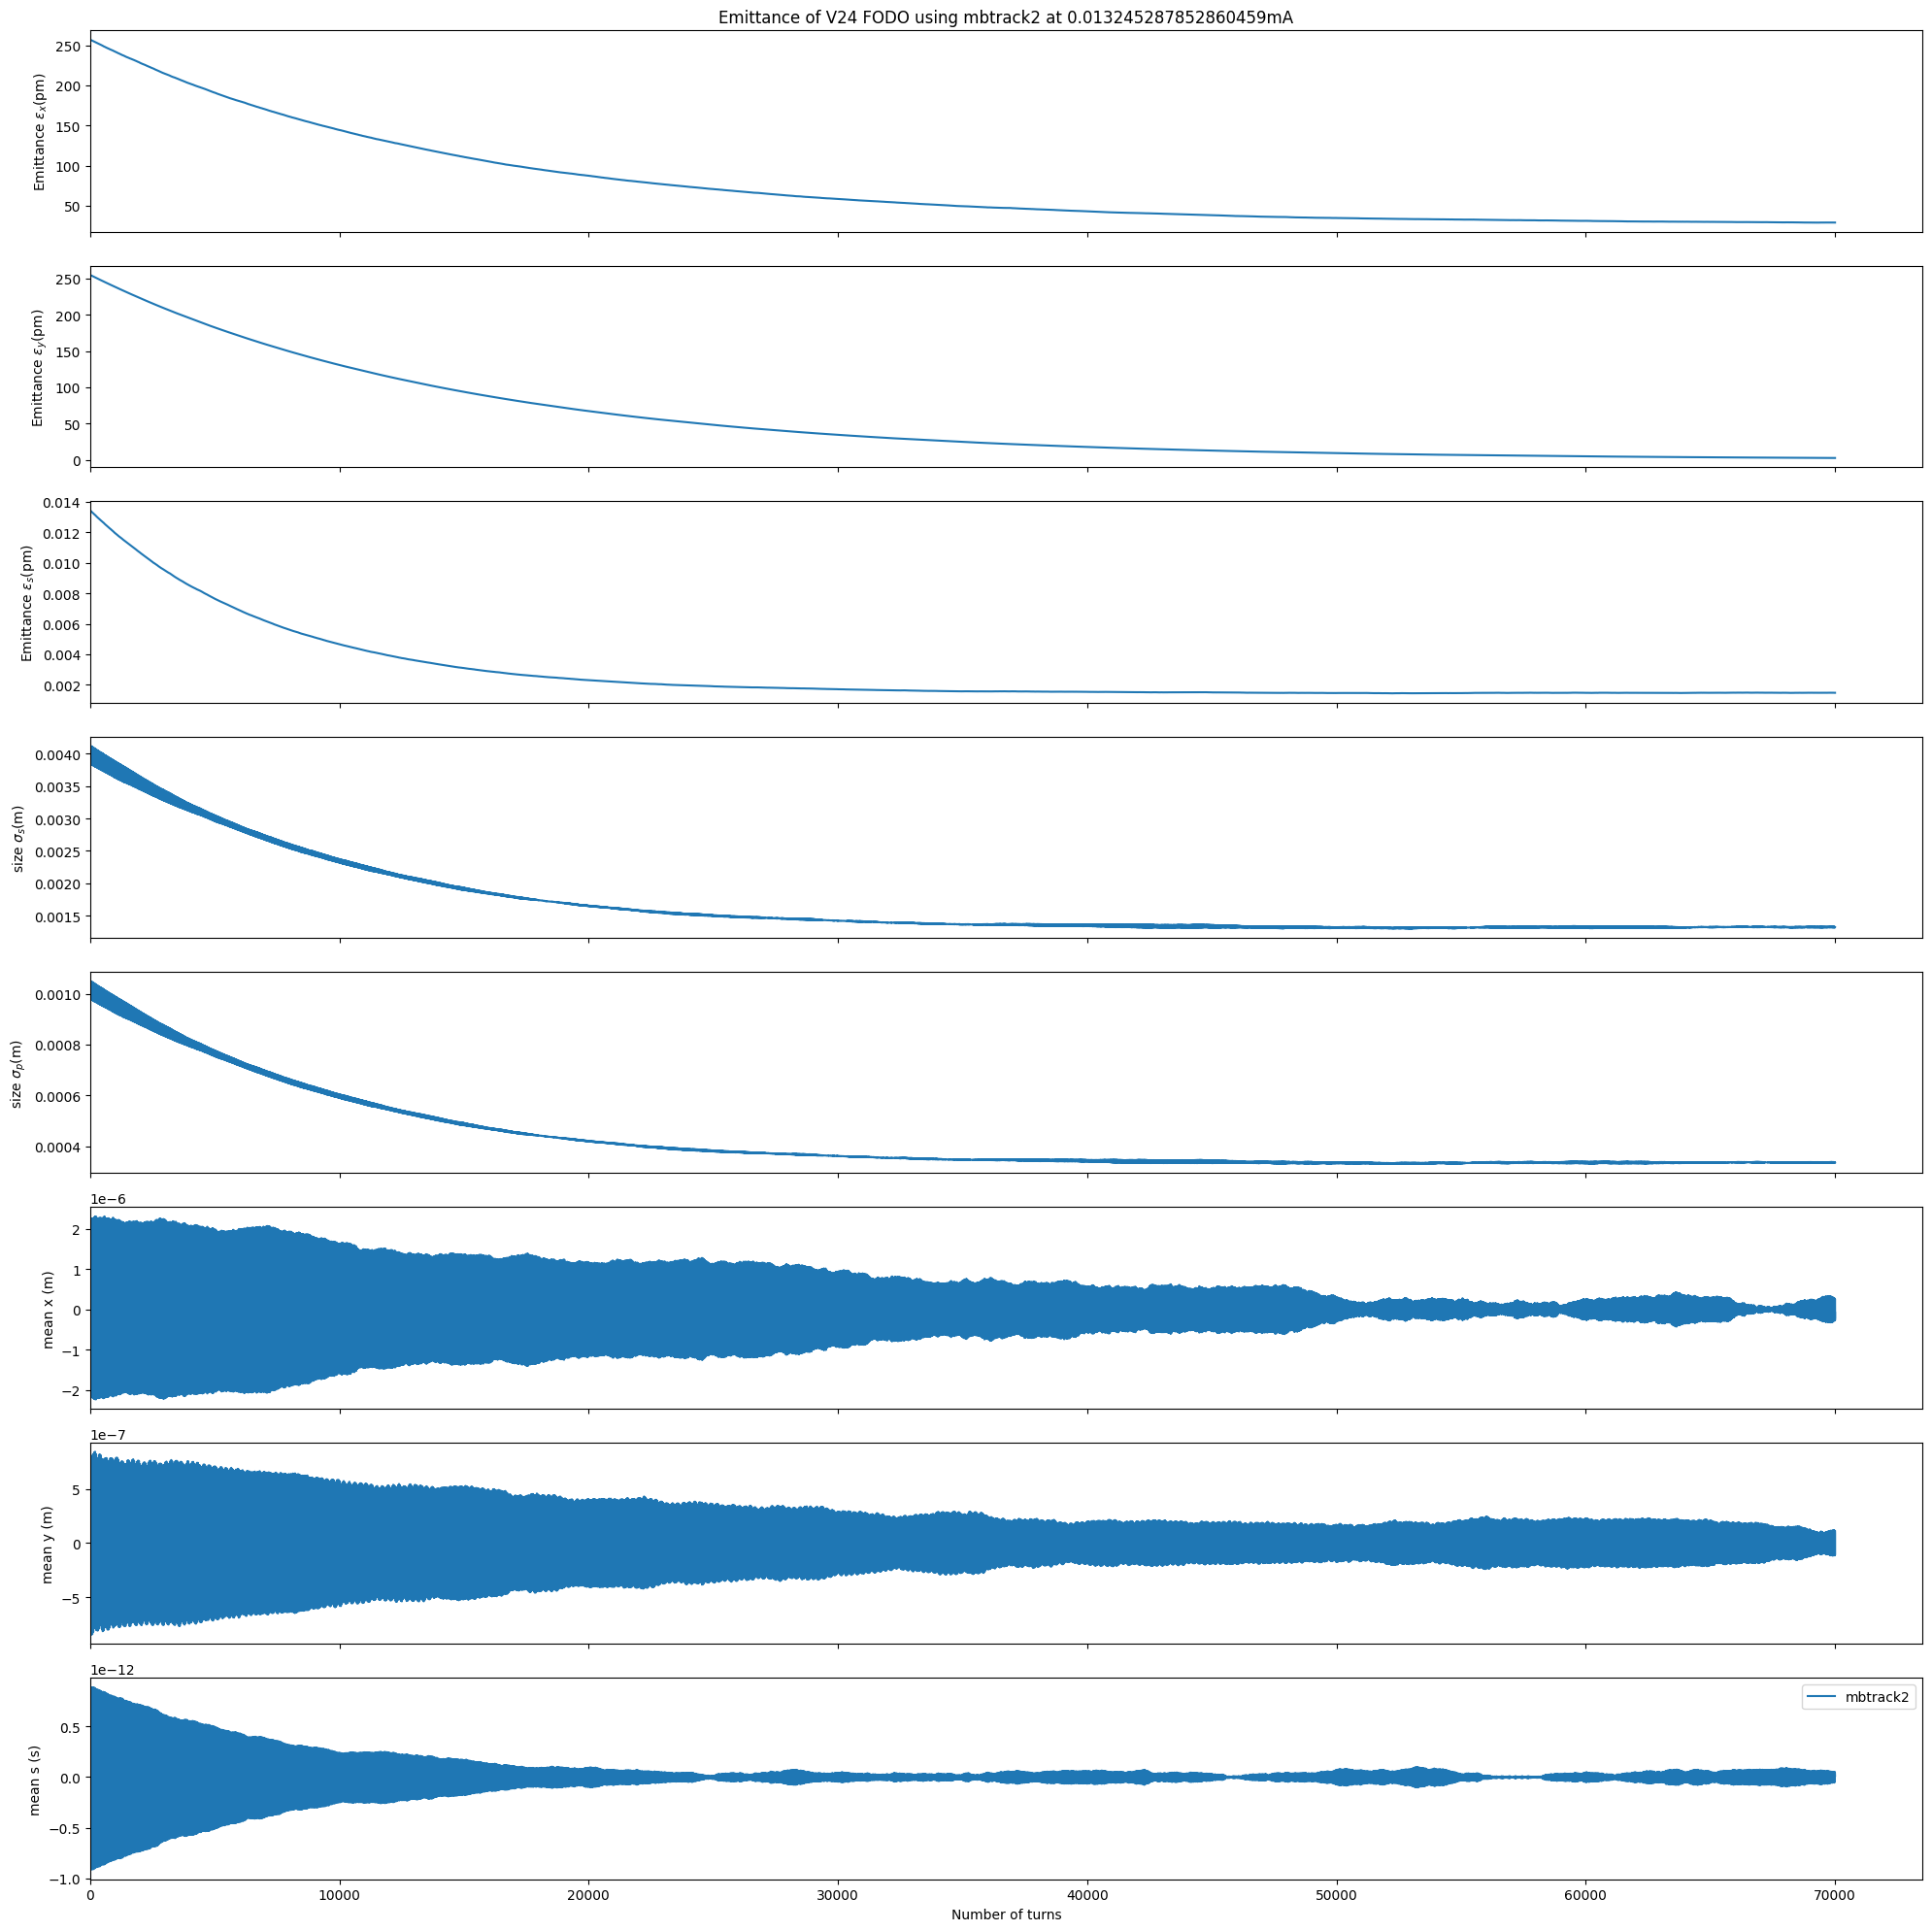

In [57]:
# plt.cla()
fig, axes = plt.subplots(8, 1, figsize=(20, 20), sharex=True)

axes[0].plot(emit[0,:]*1e12, label="mbtrack2")
axes[0].set_ylabel(r"Emittance $\epsilon_{x}$(pm)")
axes[0].set_title(f"Emittance of V24 FODO using mbtrack2 at {current*1e3: 2.5f}mA")

axes[1].plot(emit[1,:]*1e12, label="mbtrack2")
axes[1].set_ylabel(r"Emittance $\epsilon_{y}$(pm)")


axes[2].plot(emit[2,:]*1e12, label="mbtrack2")
axes[2].set_ylabel(r"Emittance $\epsilon_{s}$(pm)")


axes[3].plot(std[4,:]*cons.c, label="mbtrack2")
axes[3].set_ylabel(r"size $\sigma_{s}$(m)")


axes[4].plot(std[5,:], label="mbtrack2")
axes[4].set_ylabel(r"size $\sigma_{p}$")


axes[5].plot(mean[0,:], label="mbtrack2")
axes[5].set_ylabel(r"mean x (m)")

axes[6].plot(mean[2,:], label="mbtrack2")
axes[6].set_ylabel(r"mean y (m)")


axes[7].plot(mean[4,:], label="mbtrack2")
axes[7].set_ylabel(r"mean s (s)")
axes[7].set_xlabel("Number of turns")
plt.xlim(0,)
plt.tight_layout()

plt.legend()
plt.show()

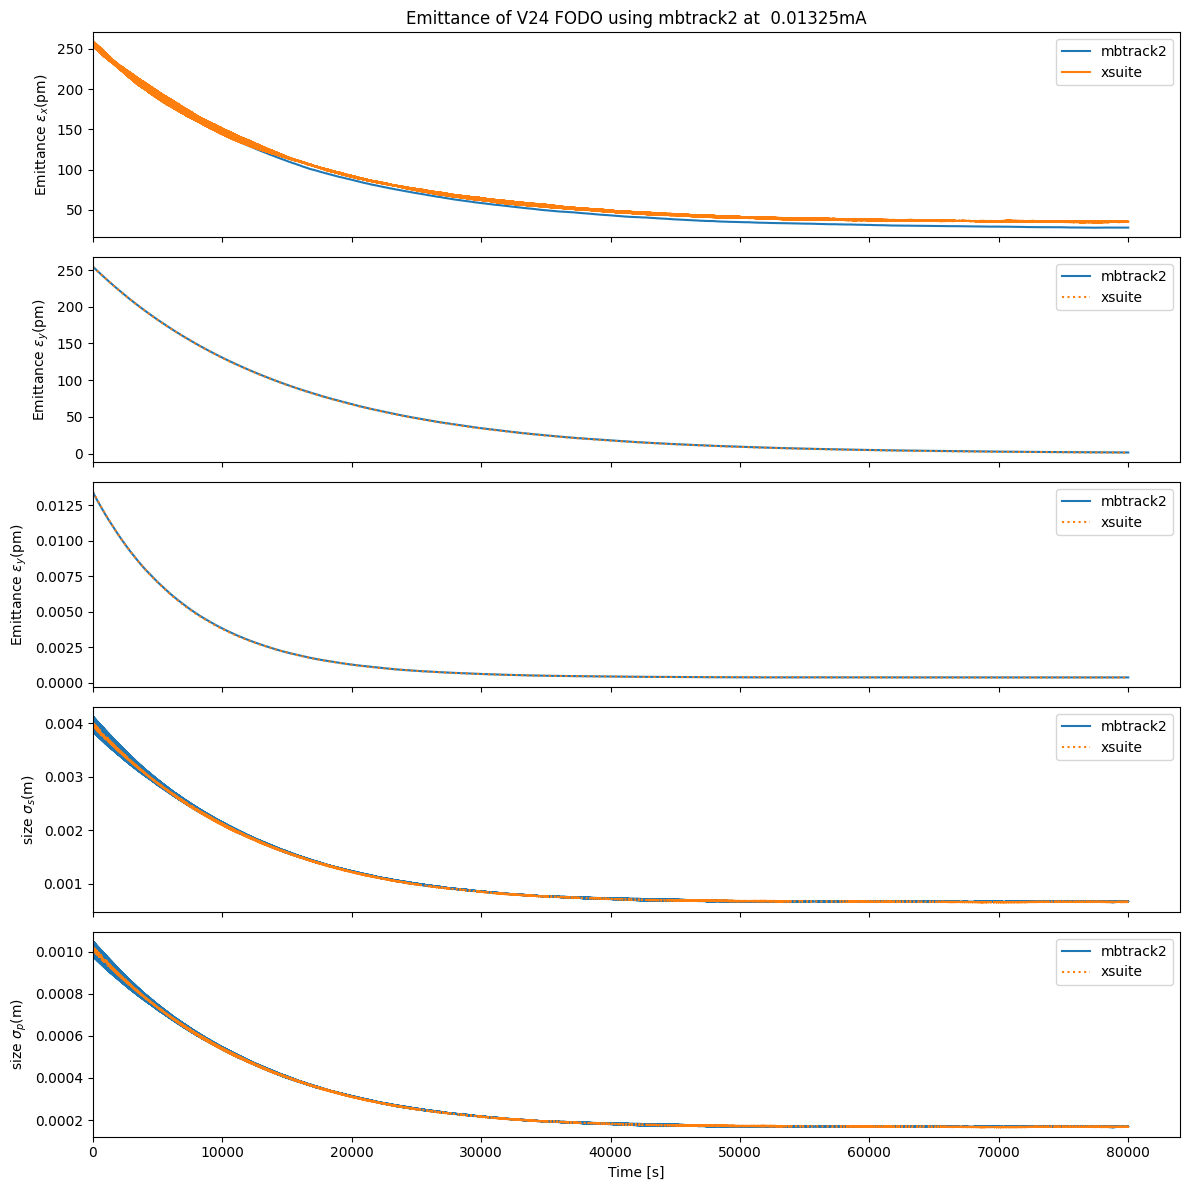

In [23]:
%matplotlib inline
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

axes[0].plot(emit[0,:]*gamma, label="mbtrack2")
axes[0].plot(emit_x*gamma, label="xsuite")
axes[0].set_ylabel(r"Emittance $\epsilon_{x}$(m)",fontsize=15)
axes[0].set_title(f"Emittance of V24 FODO using mbtrack2 at {current*1e3: 2.5f}mA")

axes[1].plot(emit[1,:]*gamma, label="mbtrack2")
axes[1].plot(emit_y*gamma, label="xsuite", ls="dotted")
axes[1].set_ylabel(r"Emittance $\epsilon_{y}$(m)", fontsize=15)

axes[2].plot(emit[2,:]*1e12, label="mbtrack2")
axes[2].plot(emit_z*1e12, label="xsuite", ls="dotted")
axes[2].set_ylabel(r"Emittance $\epsilon_{y}$(m)",fontsize=15)

axes[3].plot(std[4,:]*cons.c, label="mbtrack2")
axes[3].plot(sig_z, label="xsuite", ls="dotted")
axes[3].set_ylabel(r"size $\sigma_{s}$(m)",fontsiez=15)

axes[4].plot(std[5,:], label="mbtrack2")
axes[4].plot(sig_p, label="xsuite", ls="dotted")
axes[4].set_ylabel(r"size $\sigma_{p}$",fontsize=15)



axes[4].set_xlabel("Time [s]",fontsize=15)
plt.xlim(0,)
plt.tight_layout()
for ax in axes:
    ax.legend()

# plt.savefig("noibs delete.png",dpi=200)
plt.show()

In [31]:
import pandas as pd
# fnameref = '_inputs/other_files/IBS_files_barbara/fodo2024/ibsscan_fcc_acc_10_10_extra_fodo2024.tfs'
%matplotlib inline
fnameref = '_madx/ibsscan_fcc_acc_10_10_extra_fodo_coupl10_250701_145718_noibs.tfs'
head_opt=pd.read_csv(fnameref, header=6, delim_whitespace=True, nrows=0).columns[1:]
optics_ref=pd.read_csv(fnameref, skiprows=8, delim_whitespace=True, names=head_opt)
C = 90658.74531999999 # circumference
time = optics_ref["TT"]
turns = 3e8 * time / C
gamma = 39139.023671477466


emit_x_m = np.array(optics_ref["EXI"])
emit_y_m = np.array(optics_ref["EYI"])
# mean_x_m = np.array(optics_ref[""])
mean_y_m = np.array(outputs["meany"]["value"])
mean_z_m = np.array(outputs["meanz"]["value"])
sig_z_m = np.array(optics_ref["BL_NS"])
sig_p_m = np.array(optics_ref["DPP"])
time_m = np.array(time)

print(len(time_m))
print(len(sig_z_m))

xm = np.arange(emit[0,:].shape[0]) 
TTm = xm * D_t


# plt.cla()
# plt.plot(time,emit_x_m*1e12, label="MAD-X")
# # plt.plot(emit_x*1e12, label="Xsuite B&M")
# plt.plot(TT, emit_x*1e12, label="Xsuite B&M")
# plt.plot(TTm, emit[0,:]*1e12, label="mbtrack2")
# plt.xlabel("temps [s]")
# plt.xlim(0,)
# # plt.plot(optics_ref["V0"])
# plt.legend()
# plt.show()

1000
1000


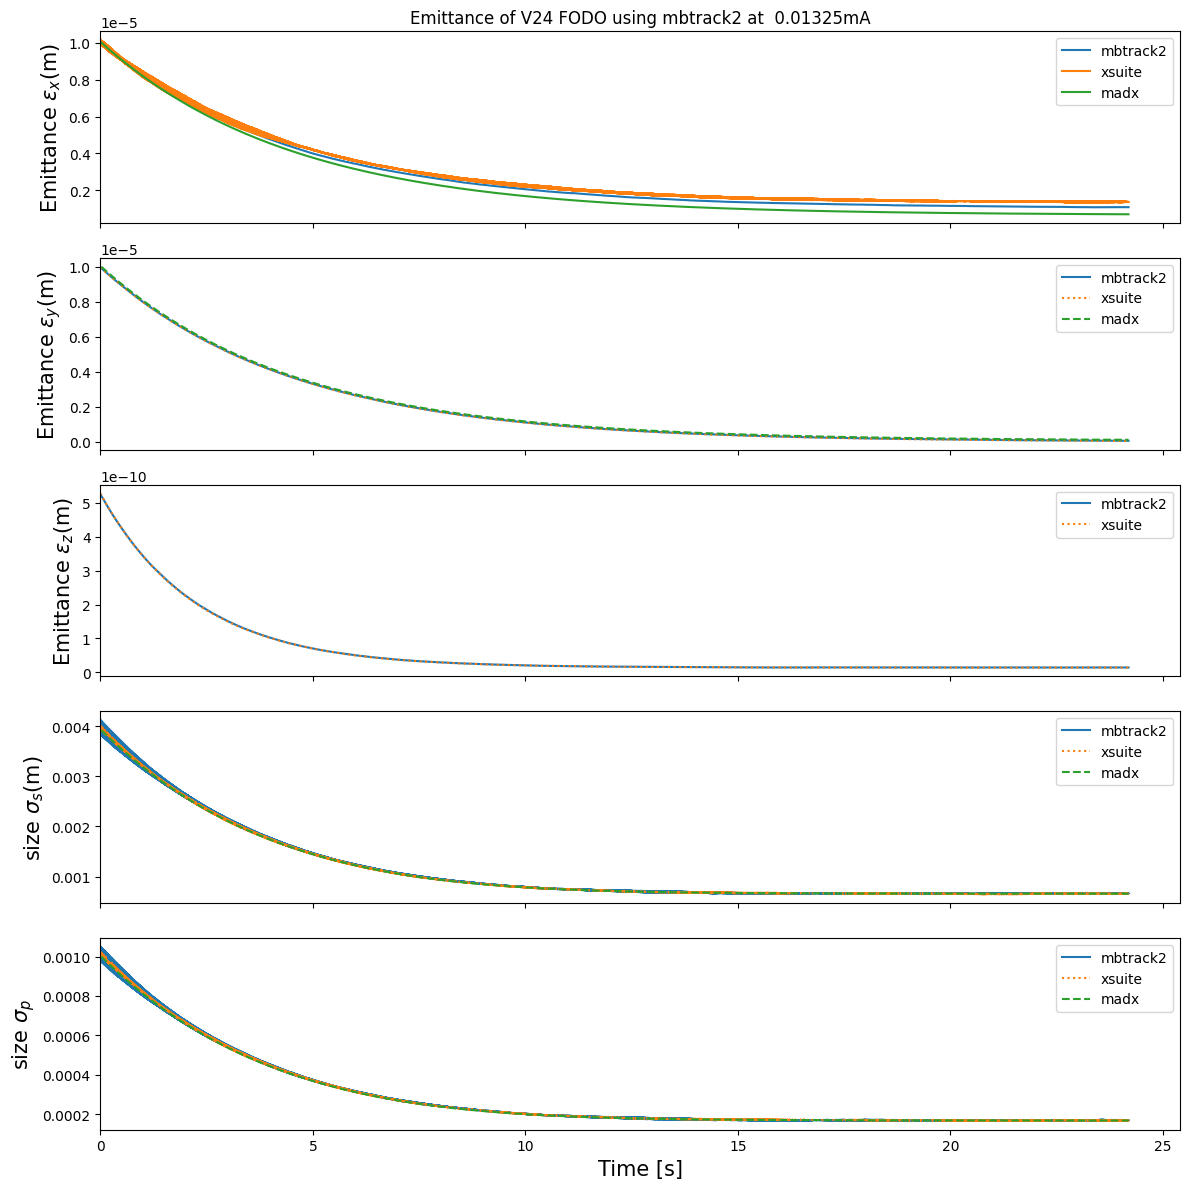

In [51]:
%matplotlib inline
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

# some_list = [emit[0,:]*1e12, emit_x*1e12, emit_x_m*1e12, emit[]
# for i in range(8):

#     for el in some_list:
#     axes[i]


axes[0].plot(TTm,emit[0,:]*gamma, label="mbtrack2")
axes[0].plot(TT,emit_x*gamma, label="xsuite")
axes[0].plot(time_m,emit_x_m*gamma, label="madx")
axes[0].set_ylabel(r"Emittance $\epsilon_{x}$(m)",fontsize=15)
axes[0].set_title(f"Emittance of V24 FODO using mbtrack2 at {current*1e3: 2.5f}mA")

axes[1].plot(TTm,emit[1,:]*gamma, label="mbtrack2")
axes[1].plot(TT,emit_y*gamma, label="xsuite", ls="dotted")
axes[1].plot(time_m,emit_y_m*gamma, label="madx", ls="dashed")
axes[1].set_ylabel(r"Emittance $\epsilon_{y}$(m)",fontsize=15)

axes[2].plot(TTm,emit[2,:]*gamma, label="mbtrack2")
axes[2].plot(TT,emit_z*gamma, label="xsuite", ls="dotted")
# axes[1].plot(time_m,emit_y_m*gamma, label="madx", ls="dashed")
axes[2].set_ylabel(r"Emittance $\epsilon_{z}$(m)",fontsize=15)

axes[3].plot(TTm,std[4,:]*cons.c, label="mbtrack2")
axes[3].plot(TT,sig_z, label="xsuite", ls="dotted")
axes[3].plot(time_m,sig_z_m, label="madx", ls="dashed")
axes[3].set_ylabel(r"size $\sigma_{s}$(m)",fontsize=15)

axes[4].plot(TTm,std[5,:], label="mbtrack2")
axes[4].plot(TT,sig_p, label="xsuite", ls="dotted")
axes[4].plot(time_m,sig_p_m, label="madx", ls="dashed")
axes[4].set_ylabel(r"size $\sigma_{p}$",fontsize=15)



axes[4].set_xlabel("Time [s]",fontsize=15)
plt.xlim(0,)
plt.tight_layout()
for ax in axes:
    ax.legend()

plt.savefig("ibs SR.png",dpi=200)

plt.show()

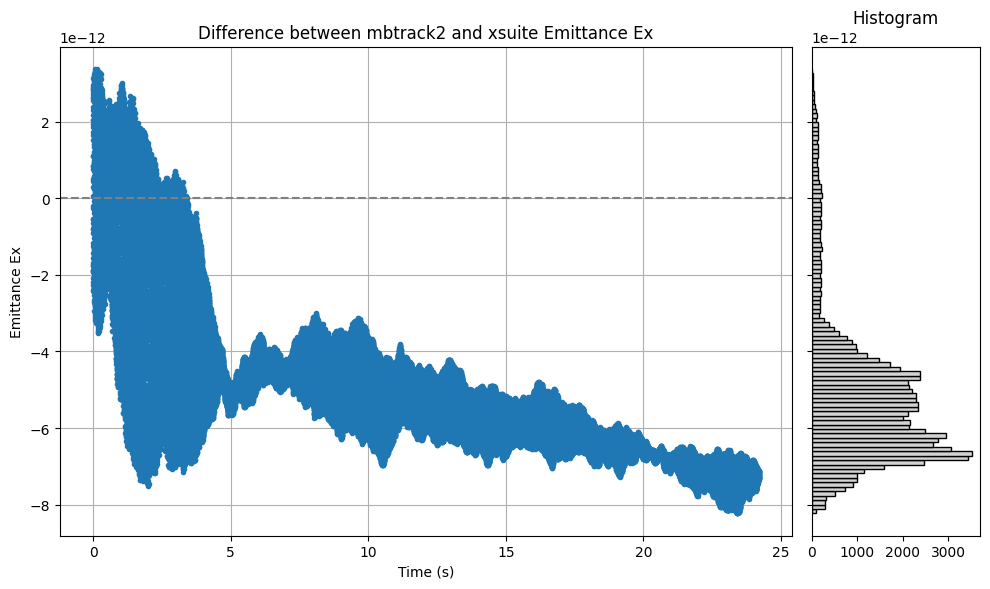

Average difference = -5.15e-12
Standard deviation =  1.96e-12
Relative Standard Deviation (RSD) =  2.82e+00 %


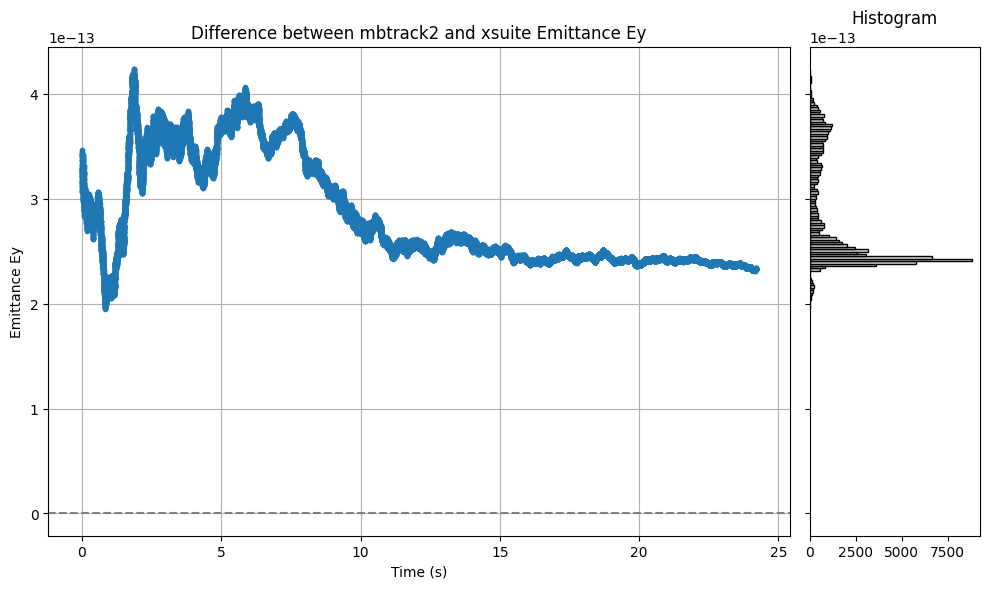

Average difference =  2.83e-13
Standard deviation =  5.18e-14
Relative Standard Deviation (RSD) =  1.09e-01 %


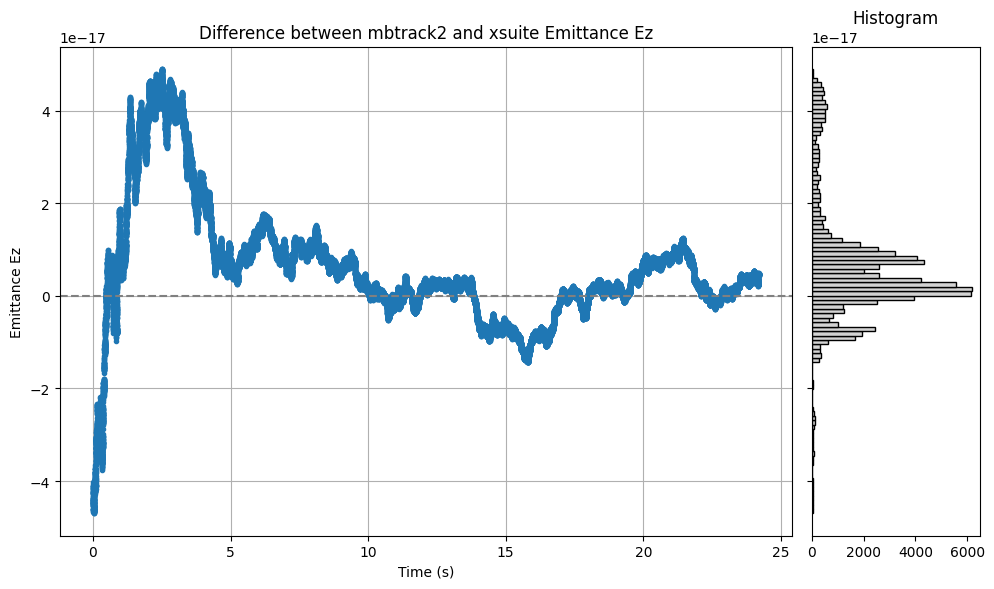

Average difference =  5.97e-18
Standard deviation =  1.33e-17
Relative Standard Deviation (RSD) =  8.32e-01 %


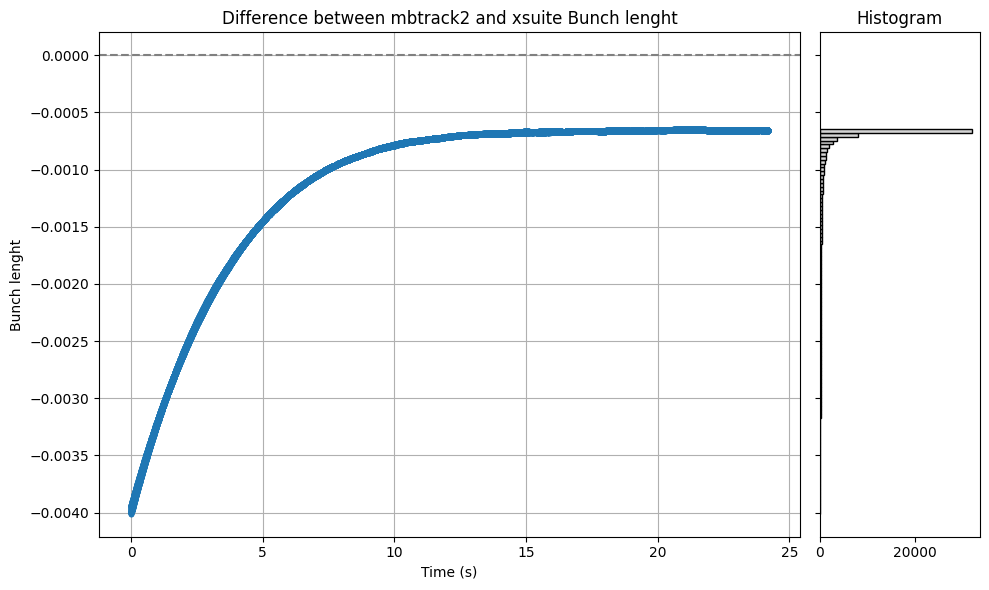

Average difference = -1.12e-03
Standard deviation =  7.79e-04
Relative Standard Deviation (RSD) =  2.07e+10 %


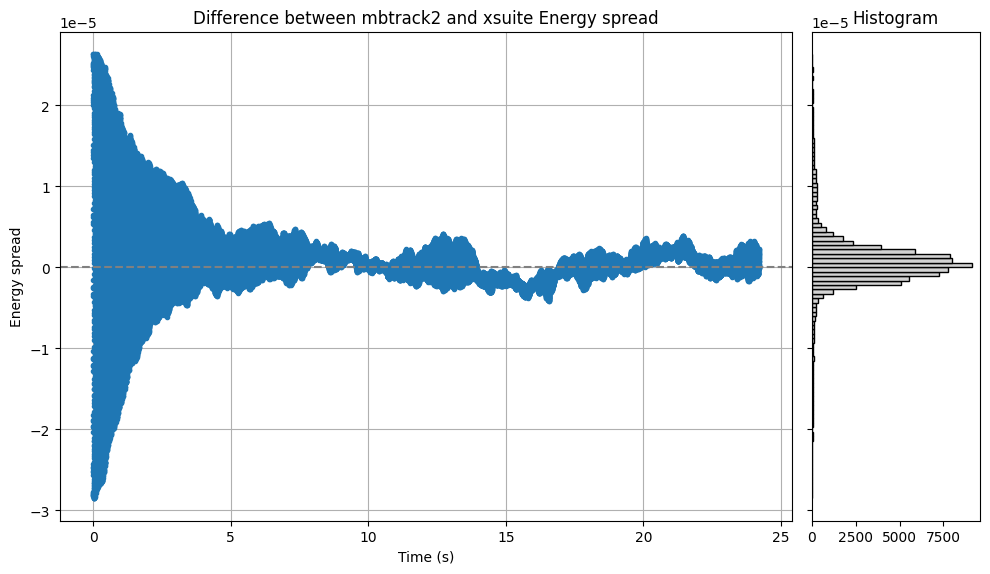

Average difference =  6.07e-07
Standard deviation =  4.43e-06
Relative Standard Deviation (RSD) =  1.54e+00 %


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

data_x = {"Emittance Ex": emit_x, "Emittance Ey": emit_y, "Emittance Ez": emit_z, "Bunch lenght": sig_z, "Energy spread": sig_p}
# data_madx = {"Emittance Ex": emit_x_m, "Emittance Ey": emit_y_m, "Emittance Ez": emit_z, "Bunch lenght": sig_z_m, "Energy spread": sig_p_m}
data_mb = {"Emittance Ex": emit[0,:], "Emittance Ey": emit[1,:], "Emittance Ez": emit[2,:], "Bunch lenght": std[4,:], "Energy spread": std[5,:]}
# data_x = [emit_x, emit_y, emit_z, sig_z, sig_p]
# data_mb = [emit[0,:], emit[1,:], emit[2,:], std[4,:], std[5,:]]

for k,v in data_x.items():
    x1 = v
    x2 = data_mb[k] 
    diff = x1 - x2
    
    fig = plt.figure(figsize=(10, 6))
    gs = GridSpec(1, 5, figure=fig)
    ax_main = fig.add_subplot(gs[0, 0:4])
    ax_hist = fig.add_subplot(gs[0, 4], sharey=ax_main)
    
    ax_main.plot(TT,diff, '.', label=k)
    ax_main.axhline(0, color='gray', linestyle='--')
    ax_main.set_ylabel(k)
    ax_main.set_xlabel("Time (s)")
    ax_main.set_title(f"Difference between mbtrack2 and xsuite {k}")
    ax_main.grid(True)
    
    ax_hist.hist(diff, bins=100, orientation='horizontal', color='lightgray', edgecolor='black')
    ax_hist.set_xlabel("")
    ax_hist.set_title("Histogram")
    
    plt.setp(ax_hist.get_yticklabels(), visible=False)
    plt.tight_layout()
    plt.savefig("err_xsuite_SR_"+k+".png",dpi=200)
    plt.show()
    
    diff_avr = np.average(diff)
    diff_std = np.std(diff)
    print(f"Average difference = {diff_avr: 2.2e}")
    print(f"Standard deviation = {diff_std: 2.2e}")
    print(f"Relative error = {diff_avr * 100 /np.average(x1): 2.2e}", "%")
    print(f"Relative Standard Deviation (RSD) = {diff_std * 100 /np.average(x1): 2.2e}", "%")
